In [4]:
pip install lime -q

In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--force-reinstall", "--no-cache-dir",
    "torch==2.7.1",
    "torchvision==0.22.1",
    "torchaudio==2.7.1",
    "transformers==4.52.4",
    "accelerate==1.7.0",
    "datasets==3.6.0",
    "evaluate==0.4.3",
    "tokenizers==0.21.1"
])

0

In [1]:
import sys
import transformers
import accelerate
import datasets
import torch

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Transformers: 4.52.4
Accelerate: 1.7.0
Datasets: 3.6.0
Torch: 2.7.1+cu126
CUDA available: True


In [2]:
# =========================================================
# 1. IMPORTS
# =========================================================
import os,csv,time,random,sys,re,subprocess,importlib.util
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset,Dataset
from transformers import RobertaTokenizer,RobertaForSequenceClassification,TrainingArguments,Trainer,DataCollatorWithPadding,TrainerCallback,EarlyStoppingCallback
from sklearn.metrics import f1_score,classification_report
from scipy.stats import pearsonr
from google.colab import drive

# =========================================================
# 2. GOOGLE DRIVE + FILES
# =========================================================
drive.mount("/content/drive")

LOG_FILE="/content/drive/MyDrive/RoBERTa_SingleStep_log.csv"
LIME_RESULT_FILE="/content/drive/MyDrive/RoBERTa_SingleStep_LIME_Results.csv"

os.makedirs("/content/drive/MyDrive",exist_ok=True)

with open(LOG_FILE,"w",newline="",encoding="utf-8") as f:
    writer=csv.writer(f)
    writer.writerow(["model","roberta-base"])
    writer.writerow(["learning_rate",2e-5])
    writer.writerow(["train_batch_size",8])
    writer.writerow(["eval_batch_size",8])
    writer.writerow(["epochs",10])
    writer.writerow([])

# =========================================================
# 3. SEED + DEVICE
# =========================================================
SEED=42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)

if torch.cuda.is_available():
    print("GPU:",torch.cuda.get_device_name(0))

# =========================================================
# 4. LOAD DATASET
# =========================================================
print("\nLoading BRIGHTER dataset...")

train_data=load_dataset("brighter-dataset/BRIGHTER-emotion-intensities","eng",split="train")
val_data=load_dataset("brighter-dataset/BRIGHTER-emotion-intensities","eng",split="dev")
test_data=load_dataset("brighter-dataset/BRIGHTER-emotion-intensities","eng",split="test")

train_df=train_data.to_pandas()
val_df=val_data.to_pandas()
test_df=test_data.to_pandas()

print("Original sizes:")
print({"train":len(train_df),"val":len(val_df),"test":len(test_df)})

# =========================================================
# 5. LABELS
# =========================================================
EMOTIONS=["anger","fear","joy","sadness","surprise"]
LEVELS=[1,2,3]
LABELS=[f"{emotion}_{level}" for emotion in EMOTIONS for level in LEVELS]
NUM_LABELS=len(LABELS)

label2id={label:i for i,label in enumerate(LABELS)}
id2label={i:label for i,label in enumerate(LABELS)}

print("Labels:",LABELS)

# =========================================================
# 6. CREATE SINGLE-STEP LABELS
# =========================================================
def convert_single_step_labels(df):
    df=df.copy()
    if "disgust" in df.columns:
        df=df.drop(columns=["disgust"])
    for emotion in EMOTIONS:
        for level in LEVELS:
            df[f"{emotion}_{level}"]=(df[emotion]==level).astype(int)
    return df

train_single=convert_single_step_labels(train_df)
val_single=convert_single_step_labels(val_df)
test_single=convert_single_step_labels(test_df)

# =========================================================
# 7. TRUE 70/20/10 SPLIT
# =========================================================
full_df=pd.concat([train_single,val_single,test_single],ignore_index=True)
full_df=full_df[["text"]+LABELS]
full_df=full_df.sample(frac=1,random_state=SEED).reset_index(drop=True)

n=len(full_df)
train_end=int(0.7*n)
val_end=int(0.9*n)

train_single=full_df[:train_end].reset_index(drop=True)
val_single=full_df[train_end:val_end].reset_index(drop=True)
test_single=full_df[val_end:].reset_index(drop=True)

print("New split sizes:")
print({"train":len(train_single),"val":len(val_single),"test":len(test_single)})

test_texts=test_single["text"].tolist()

# =========================================================
# 8. CONVERT TO HF DATASETS
# =========================================================
train_single=Dataset.from_pandas(train_single,preserve_index=False)
val_single=Dataset.from_pandas(val_single,preserve_index=False)
test_single=Dataset.from_pandas(test_single,preserve_index=False)

# =========================================================
# 9. TOKENIZATION
# =========================================================
tokenizer=RobertaTokenizer.from_pretrained("roberta-base")
data_collator=DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(examples):
    return tokenizer(examples["text"],truncation=True,max_length=128)

train_single=train_single.map(tokenize_function,batched=True)
val_single=val_single.map(tokenize_function,batched=True)
test_single=test_single.map(tokenize_function,batched=True)

# =========================================================
# 10. ADD LABELS
# =========================================================
def add_labels(example):
    example["labels"]=[float(example[label]) for label in LABELS]
    return example

train_single=train_single.map(add_labels)
val_single=val_single.map(add_labels)
test_single=test_single.map(add_labels)

train_single.set_format(type="torch",columns=["input_ids","attention_mask","labels"])
val_single.set_format(type="torch",columns=["input_ids","attention_mask","labels"])
test_single.set_format(type="torch",columns=["input_ids","attention_mask","labels"])

# =========================================================
# 11. METRICS
# =========================================================
def compute_metrics(eval_pred):
    logits,labels=eval_pred
    probs=1/(1+np.exp(-logits))
    preds=(probs>=0.5).astype(int)

    f1_macro=f1_score(labels,preds,average="macro",zero_division=0)
    f1_micro=f1_score(labels,preds,average="micro",zero_division=0)

    pearsons=[]
    for i in range(labels.shape[1]):
        if np.std(labels[:,i])==0 or np.std(probs[:,i])==0:
            pearsons.append(0.0)
        else:
            p,_=pearsonr(labels[:,i],probs[:,i])
            pearsons.append(0.0 if np.isnan(p) else float(p))

    return {
        "f1_macro":f1_macro,
        "f1_micro":f1_micro,
        "pearson_mean":float(np.mean(pearsons))
    }

# =========================================================
# 12. CALLBACK
# =========================================================
class SaveEpochResultsCallback(TrainerCallback):
    def __init__(self,file_path,test_dataset):
        self.file_path=file_path
        self.test_dataset=test_dataset
        self.trainer_ref=None
        self.current_train_loss=None
        self._inside_eval=False

    def on_log(self,args,state,control,logs=None,**kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss=float(logs["loss"])

    def on_evaluate(self,args,state,control,metrics=None,**kwargs):
        if self._inside_eval or metrics is None or "eval_loss" not in metrics:
            return

        self._inside_eval=True

        try:
            epoch=int(round(float(metrics.get("epoch",state.epoch))))
            train_loss=self.current_train_loss if self.current_train_loss is not None else ""

            val_loss=float(metrics.get("eval_loss",0.0))
            val_f1_macro=float(metrics.get("eval_f1_macro",0.0))
            val_f1_micro=float(metrics.get("eval_f1_micro",0.0))
            val_pearson=float(metrics.get("eval_pearson_mean",0.0))

            pred=self.trainer_ref.predict(self.test_dataset,metric_key_prefix="test")

            test_loss=float(pred.metrics.get("test_loss",0.0))
            test_f1_macro=float(pred.metrics.get("test_f1_macro",0.0))
            test_f1_micro=float(pred.metrics.get("test_f1_micro",0.0))
            test_pearson=float(pred.metrics.get("test_pearson_mean",0.0))

            true_labels=pred.label_ids.astype(int)
            probs=1/(1+np.exp(-pred.predictions))
            pred_labels=(probs>=0.5).astype(int)

            report=classification_report(
                true_labels,
                pred_labels,
                target_names=LABELS,
                zero_division=0,
                output_dict=True
            )

            with open(self.file_path,"a",newline="",encoding="utf-8") as file:
                writer=csv.writer(file)

                writer.writerow([])
                writer.writerow([f"EPOCH {epoch}"])
                writer.writerow([
                    "epoch","train_loss","val_loss","test_loss",
                    "val_f1_macro","val_f1_micro","test_f1_macro",
                    "test_f1_micro","val_pearson_mean","test_pearson_mean"
                ])

                writer.writerow([
                    epoch,train_loss,val_loss,test_loss,
                    val_f1_macro,val_f1_micro,test_f1_macro,
                    test_f1_micro,val_pearson,test_pearson
                ])

                writer.writerow([])
                writer.writerow([f"CLASSWISE RESULTS AFTER EPOCH {epoch}"])
                writer.writerow([
                    "class","precision","recall","f1_score",
                    "TP","TN","FN","FP","support"
                ])

                for class_index,class_name in enumerate(LABELS):
                    row=report.get(class_name,{})
                    true_class=true_labels[:,class_index]
                    pred_class=pred_labels[:,class_index]

                    tp=int(np.sum((true_class==1)&(pred_class==1)))
                    tn=int(np.sum((true_class==0)&(pred_class==0)))
                    fn=int(np.sum((true_class==1)&(pred_class==0)))
                    fp=int(np.sum((true_class==0)&(pred_class==1)))

                    writer.writerow([
                        class_name,
                        row.get("precision",""),
                        row.get("recall",""),
                        row.get("f1-score",""),
                        tp,tn,fn,fp,
                        row.get("support","")
                    ])

            print(f"Epoch {epoch} results saved.")

        finally:
            self._inside_eval=False

# =========================================================
# 13. MODEL
# =========================================================
model=RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

# =========================================================
# 14. TRAINING ARGUMENTS
# =========================================================
training_args=TrainingArguments(
    output_dir="/content/roberta_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

# =========================================================
# 15. TRAINER
# =========================================================
callback=SaveEpochResultsCallback(LOG_FILE,test_single)

trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=train_single,
    eval_dataset=val_single,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[
        callback,
        EarlyStoppingCallback(
            early_stopping_patience=1,
            early_stopping_threshold=0.0
        )
    ]
)

callback.trainer_ref=trainer

# =========================================================
# 16. TRAIN
# =========================================================
start=time.time()
trainer.train()
end=time.time()

print(f"Training time: {end-start:.1f} seconds")
print("Best checkpoint:",trainer.state.best_model_checkpoint)

# =========================================================
# 17. FINAL TEST PREDICTIONS
# =========================================================
final_output=trainer.predict(test_single,metric_key_prefix="final_test")

final_logits=final_output.predictions
final_true_labels=final_output.label_ids.astype(int)
final_probs=1/(1+np.exp(-final_logits))
final_predictions=(final_probs>=0.5).astype(int)

final_report=classification_report(
    final_true_labels,
    final_predictions,
    target_names=LABELS,
    zero_division=0,
    output_dict=True
)



Mounted at /content/drive
Using device: cuda
GPU: Tesla T4

Loading BRIGHTER dataset...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

eng/train-00000-of-00001.parquet:   0%|          | 0.00/179k [00:00<?, ?B/s]

eng/dev-00000-of-00001.parquet:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

...

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,Pearson Mean
1,0.308600,0.270475,0.024440,0.051585,0.280611
2,0.250800,0.245216,0.127966,0.177632,0.411228
3,0.214300,0.235482,0.188426,0.253705,0.440191
4,0.186700,0.230233,0.282333,0.380512,0.461322
5,0.160900,0.235222,0.325802,0.409950,0.467977


Epoch 1 results saved.
Epoch 2 results saved.
Epoch 3 results saved.
Epoch 4 results saved.
Epoch 5 results saved.
Training time: 301.8 seconds
Best checkpoint: /content/roberta_output/checkpoint-1976



AGGREGATED LIME ANALYSIS

----------------------------------------------------------------------
[1/15] anger_1
True class sentences: 36
Predicted class sentences: 6
anger_1 true class sentences: 20/36
anger_1 true class sentences: 36/36
anger_1 class predictions: 6/6

----------------------------------------------------------------------
[2/15] anger_2
True class sentences: 15
Predicted class sentences: 4
anger_2 true class sentences: 15/15
anger_2 class predictions: 4/4

----------------------------------------------------------------------
[3/15] anger_3
True class sentences: 9
Predicted class sentences: 0
anger_3 true class sentences: 9/9

----------------------------------------------------------------------
[4/15] fear_1
True class sentences: 159
Predicted class sentences: 156
fear_1 true class sentences: 20/159
fear_1 true class sentences: 40/159
fear_1 true class sentences: 60/159
fear_1 true class sentences: 80/159
fear_1 true class sentences: 100/159
fear_1 true class senten

,class,recall,precision,fnr,TP,TN,FN,FP,support,true_class_lime_words,predicted_class_lime_words
0,anger_1,0.0556,0.3333,0.9444,2,525,34,4,36,upset (0.5128); objected (0.4322); messed (0.4...,messed (0.4277); broke (0.2268); this (0.1965)...
1,anger_2,0.0667,0.2500,0.9333,1,547,14,3,15,hell (0.5318); asshole (0.3157); anger (0.2959...,rage (0.4014); fucking (0.2301); destroying (0...
2,anger_3,0.0000,0.0000,1.0000,0,556,9,0,9,rage (0.2606); fucking (0.1195); pissed (0.098...,NO CLASS PREDICTIONS
3,fear_1,0.4151,0.4231,0.5849,66,316,93,90,159,hurt (1.4600); the (1.0665); weird (1.0647); t...,weird (1.5803); hurt (1.3168); to (1.2576); i ...
4,fear_2,0.2929,0.3718,0.7071,29,417,70,49,99,i (2.2463); and (1.8047); my (1.4011); to (1.0...,i (2.2652); blood (2.0021); and (1.8351); my (...
5,fear_3,0.4200,0.7500,0.5800,21,508,29,7,50,freaked (2.2808); danger (1.0095); black (1.00...,freaked (2.8844); black (1.0155); danger (1.01...
6,joy_1,0.5055,0.5412,0.4945,46,435,45,39,91,i (1.8636); my (1.7632); a (0.9355); attractiv...,i (2.4219); my (1.5615); a (1.1855); happy (0....
7,joy_2,0.3226,0.4762,0.6774,10,523,21,11,31,grin (0.5287); fun (0.5216); smile (0.4856); g...,smile (1.2611); awesome (0.9903); love (0.8058...
8,joy_3,0.0000,0.0000,1.0000,0,553,12,0,12,awesome (1.1952); happiness (0.2540); cheered ...,NO CLASS PREDICTIONS
9,sadness_1,0.2828,0.4590,0.7172,28,433,71,33,99,hurt (1.4131); my (1.3094); i (1.2832); and (0...,my (1.2643); i (0.9652); pain (0.7930); and (0...



Saved: /content/drive/MyDrive/RoBERTa_SingleStep_LIME_Results.csv


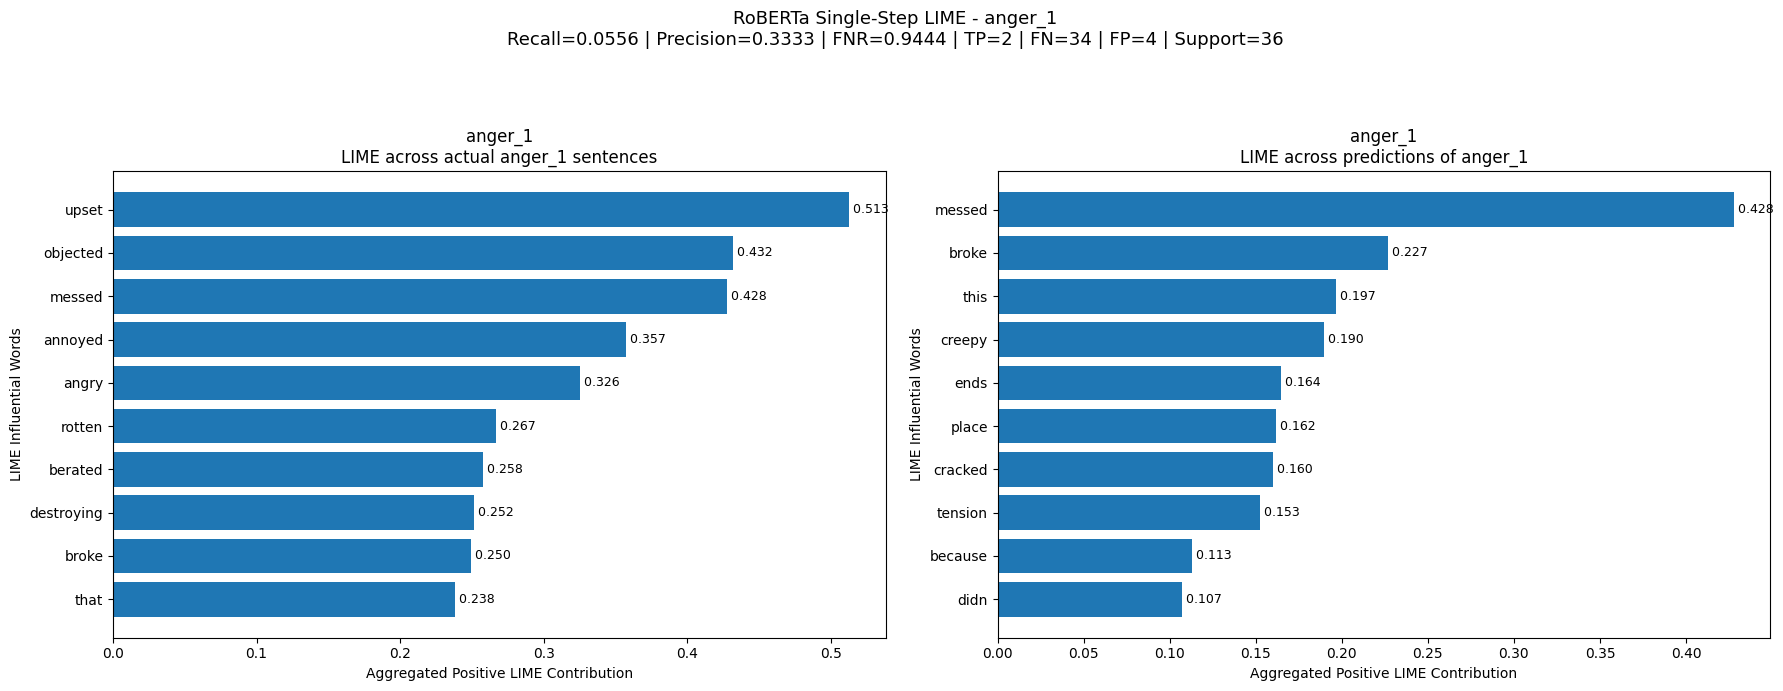

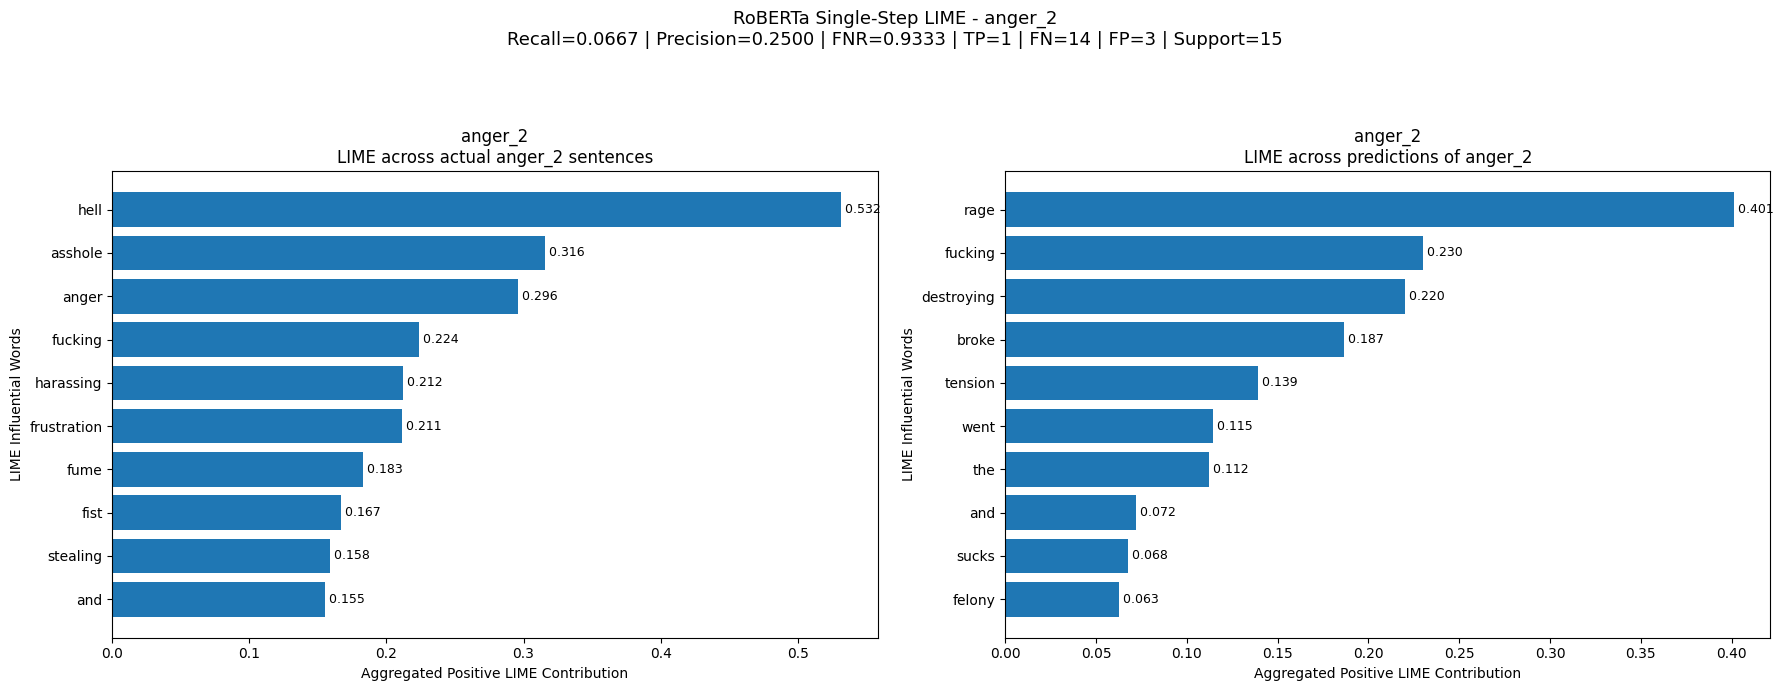

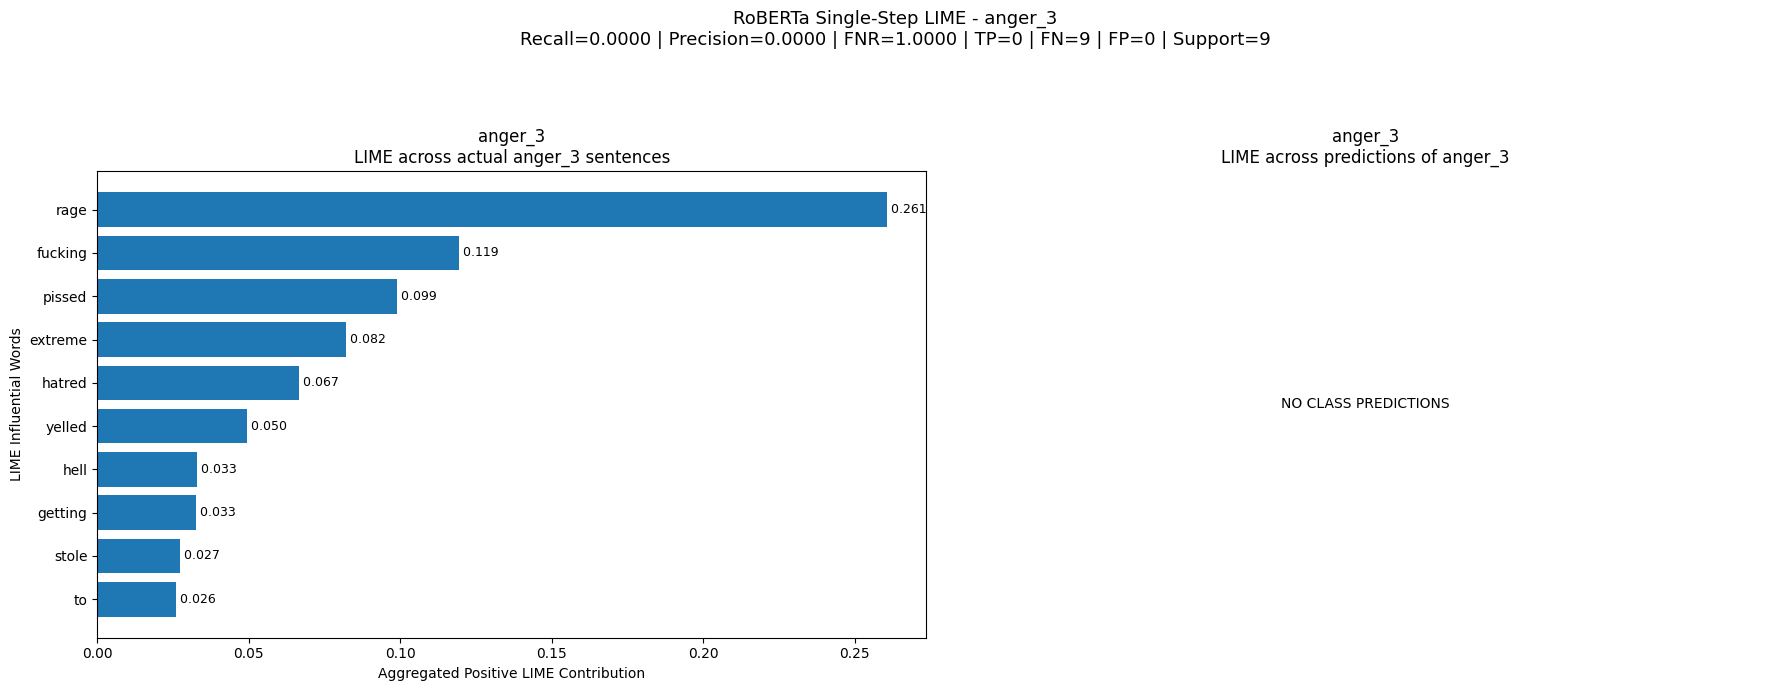

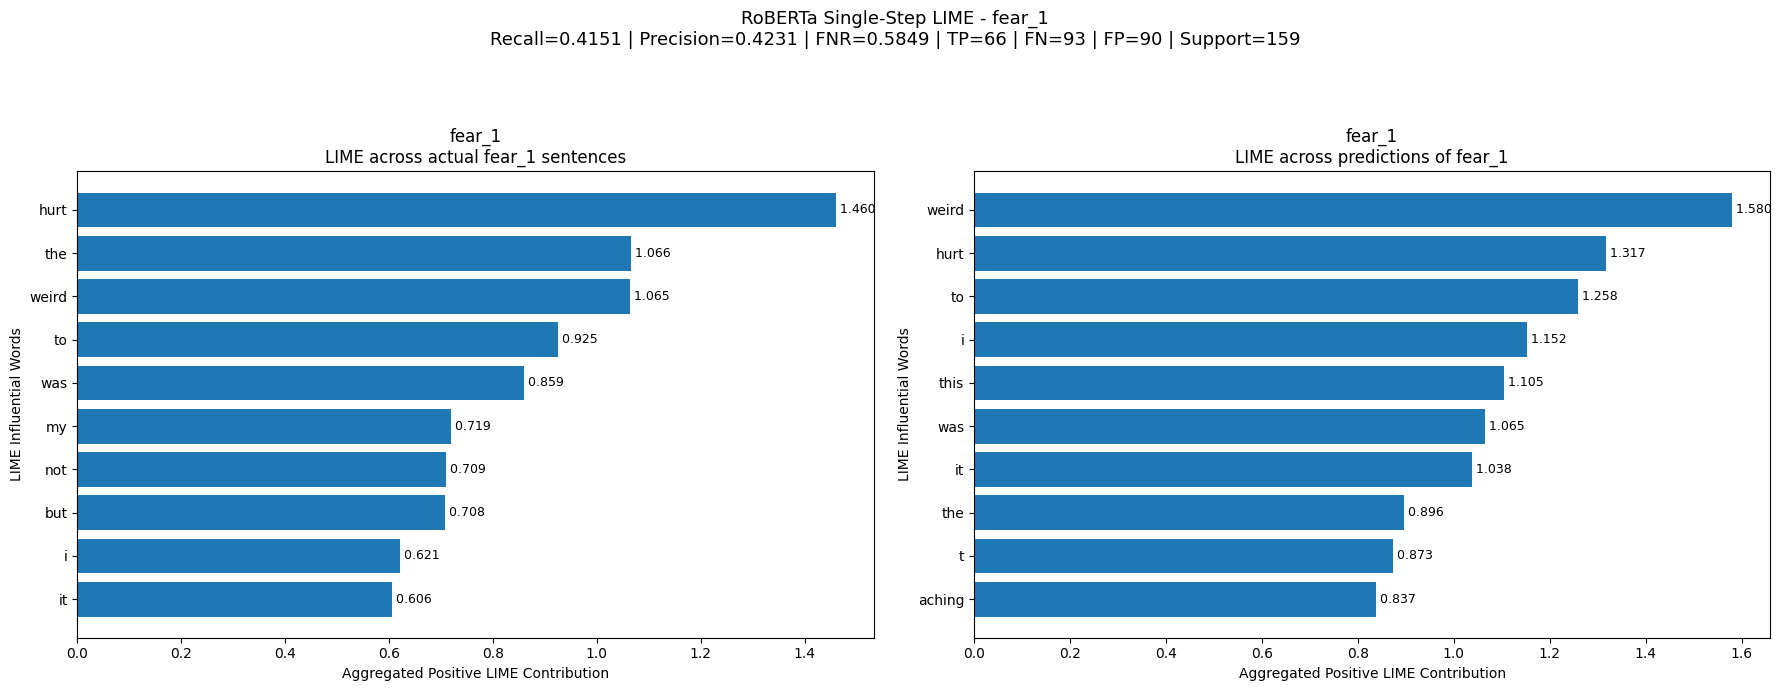

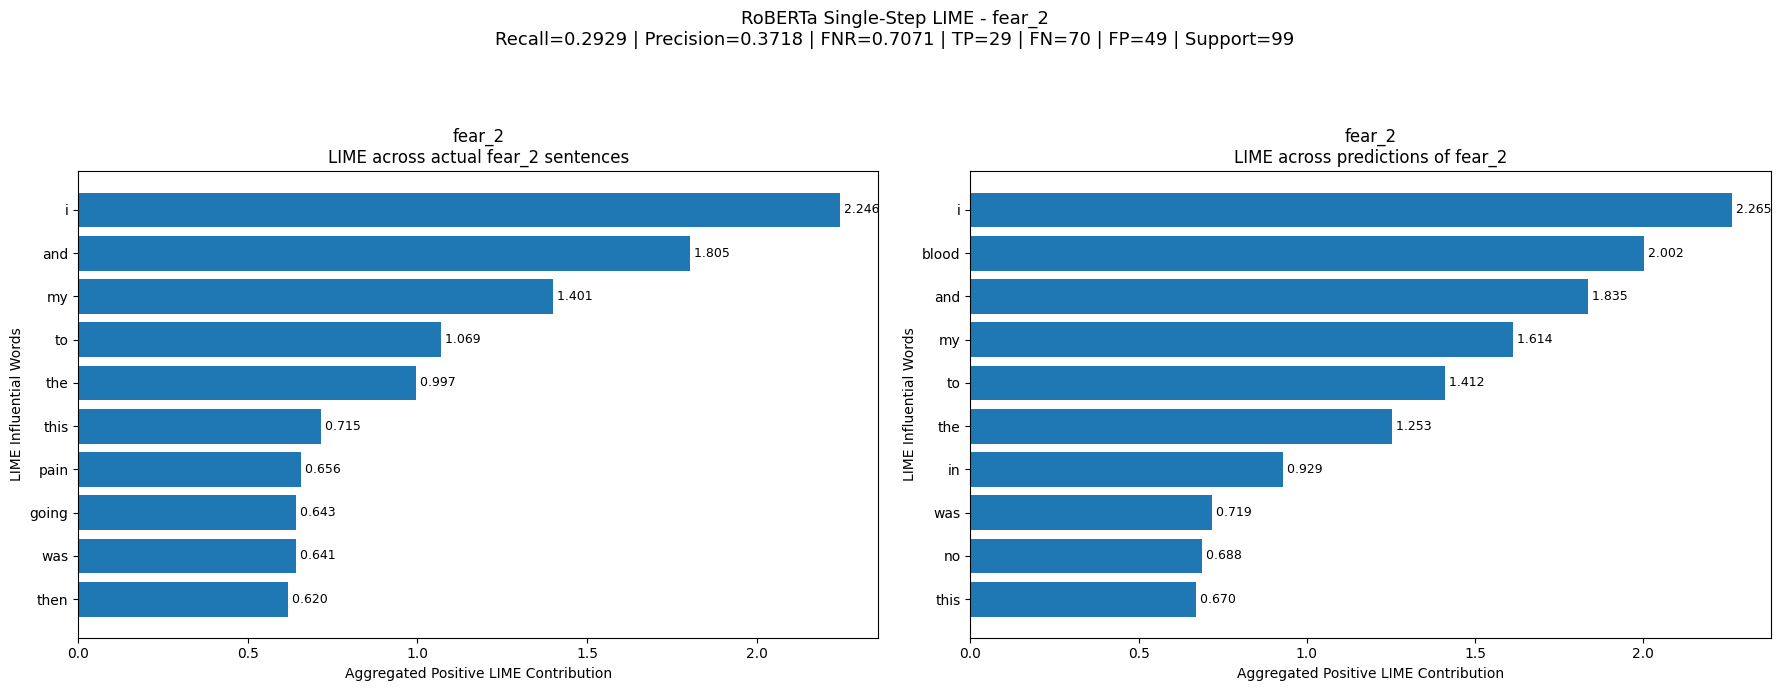

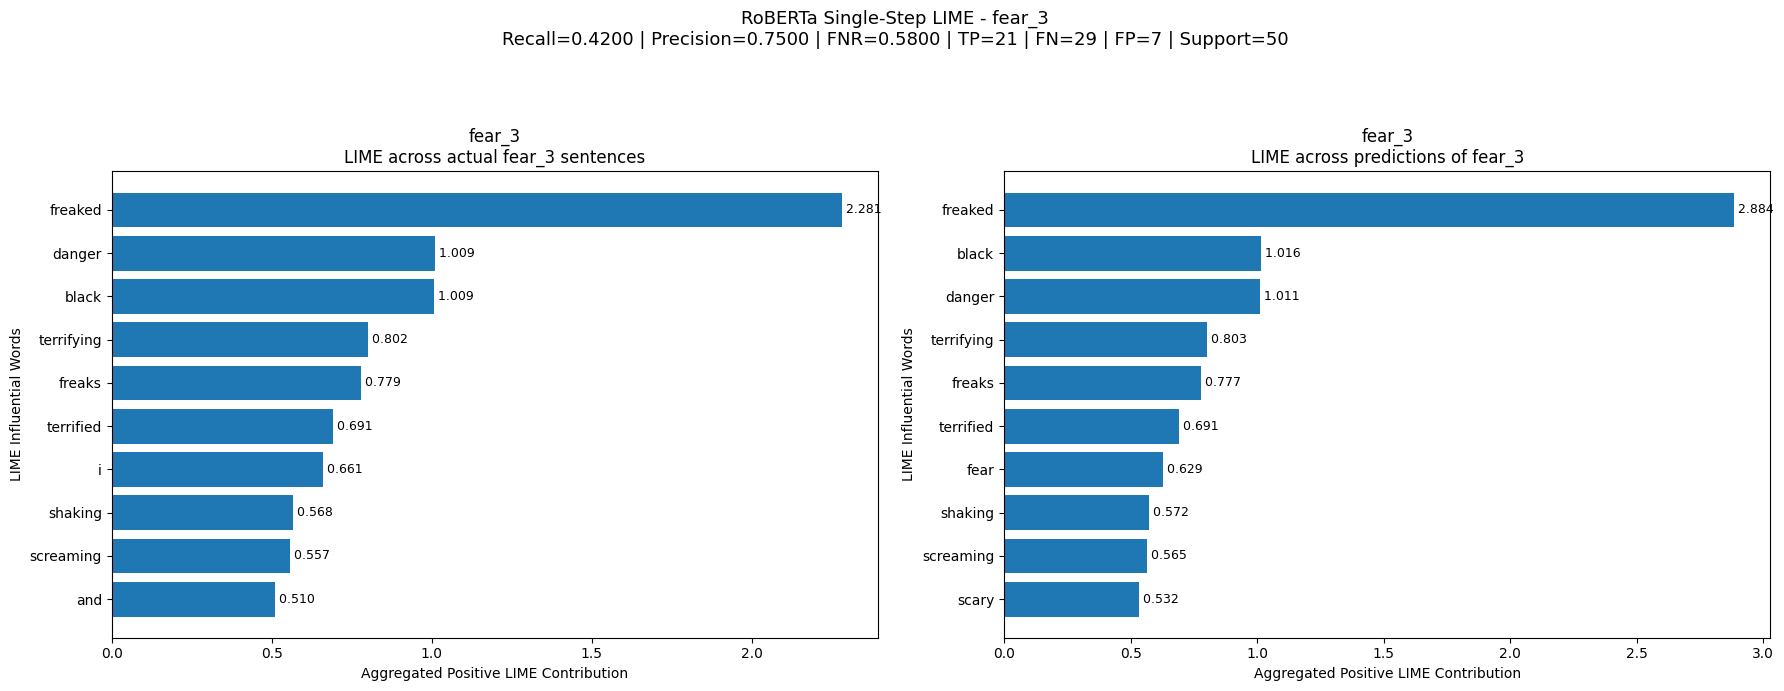

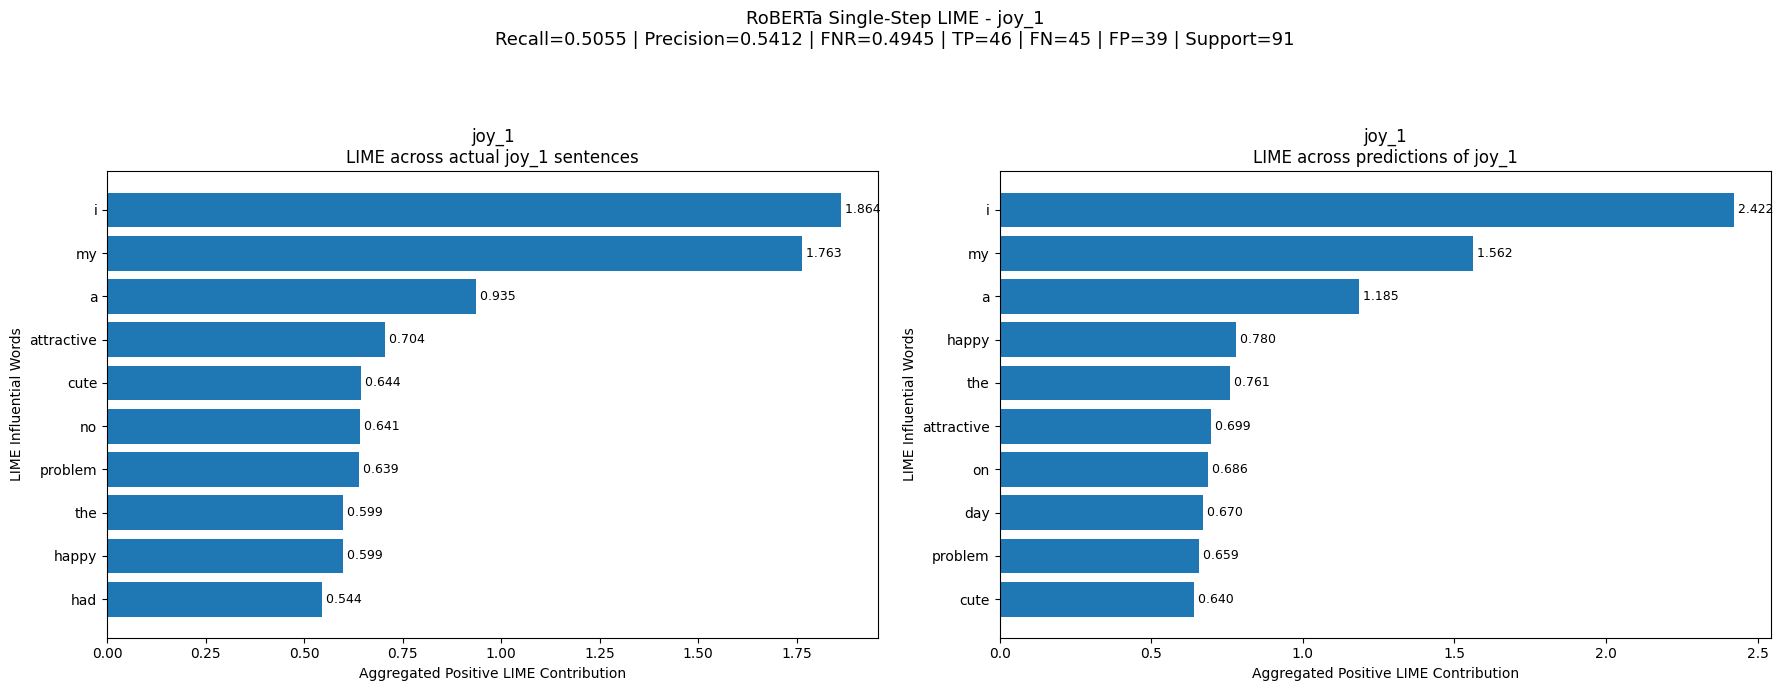

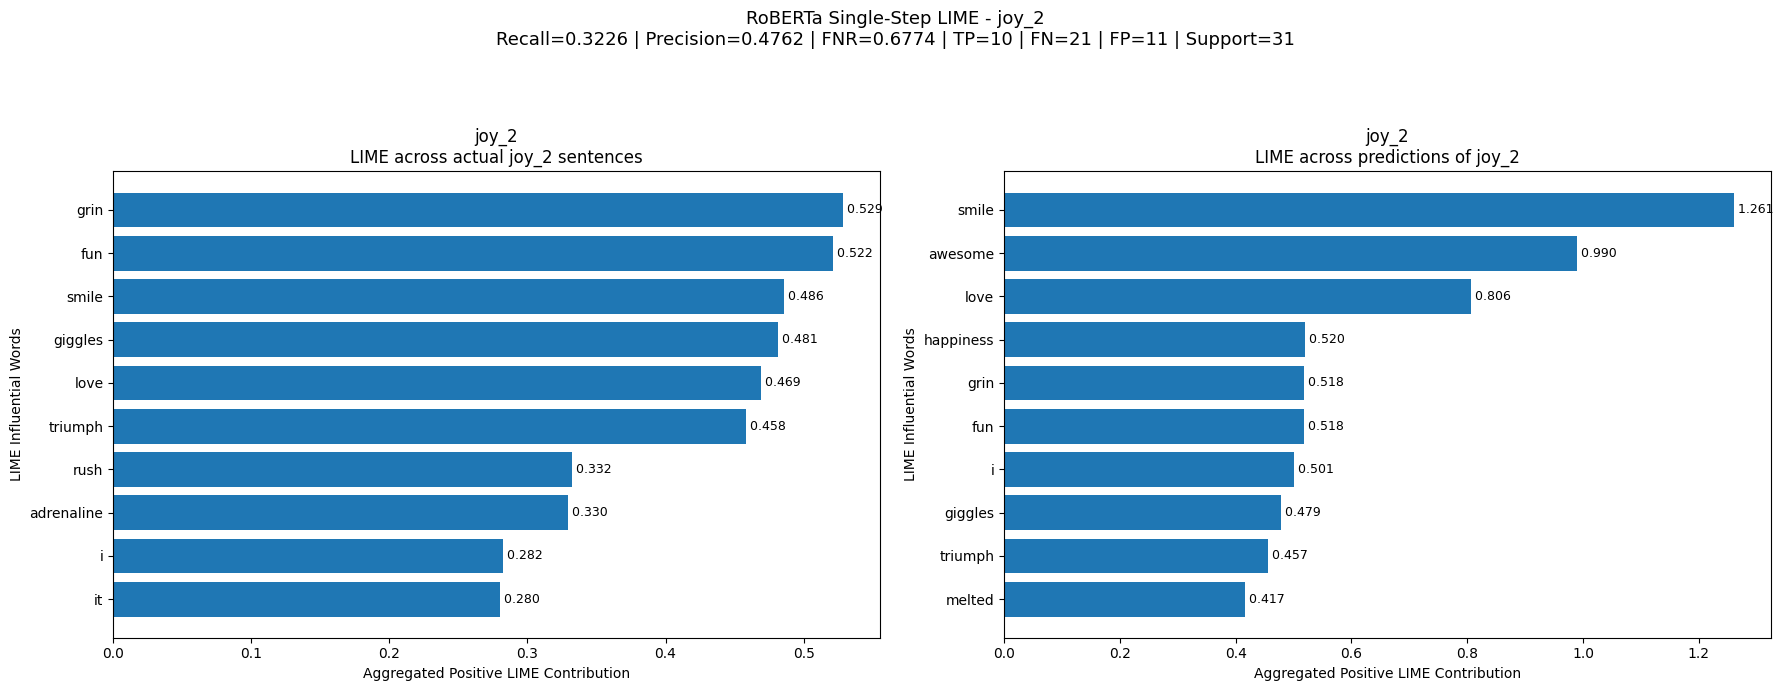

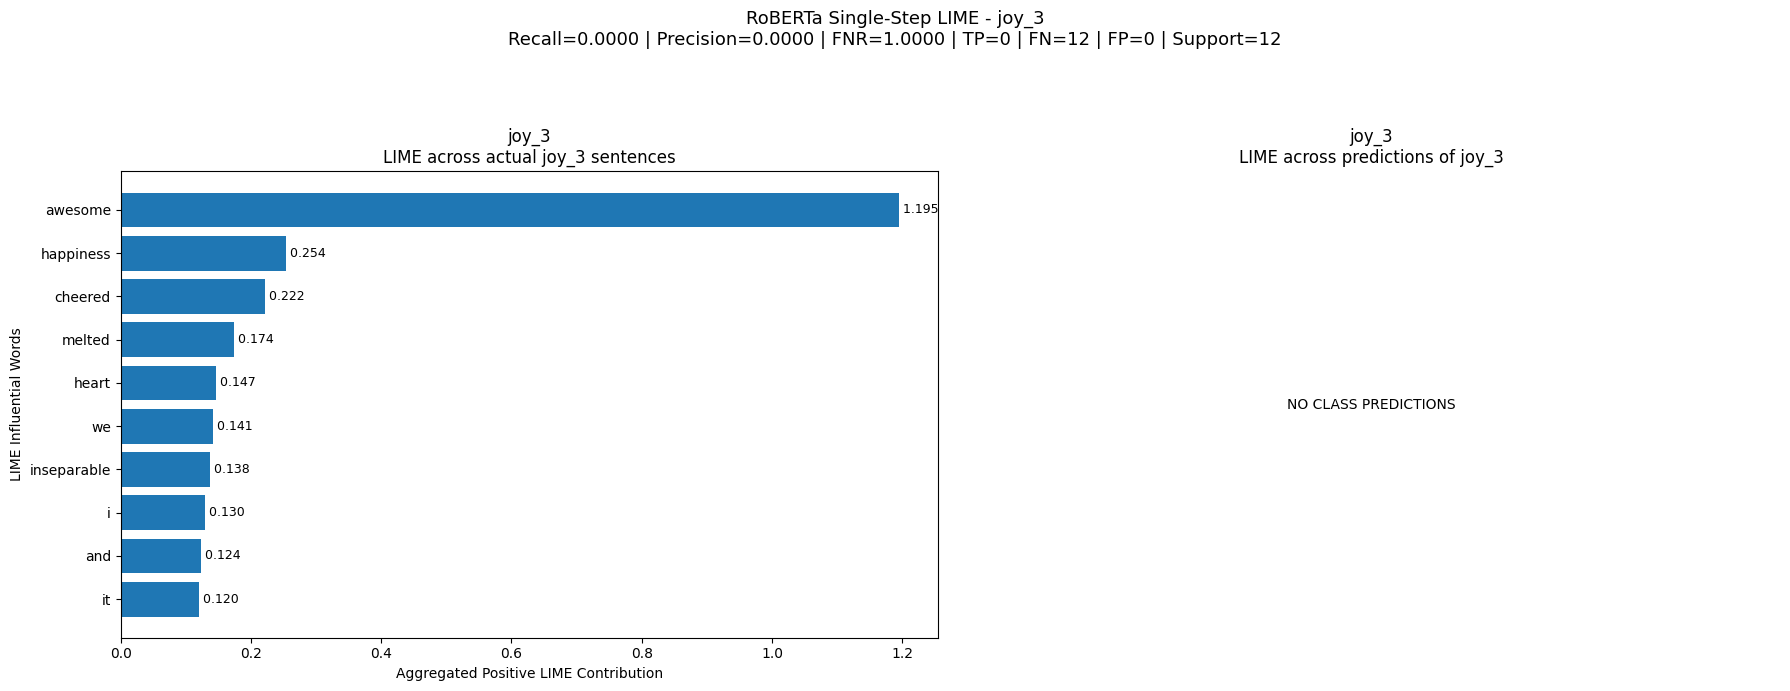

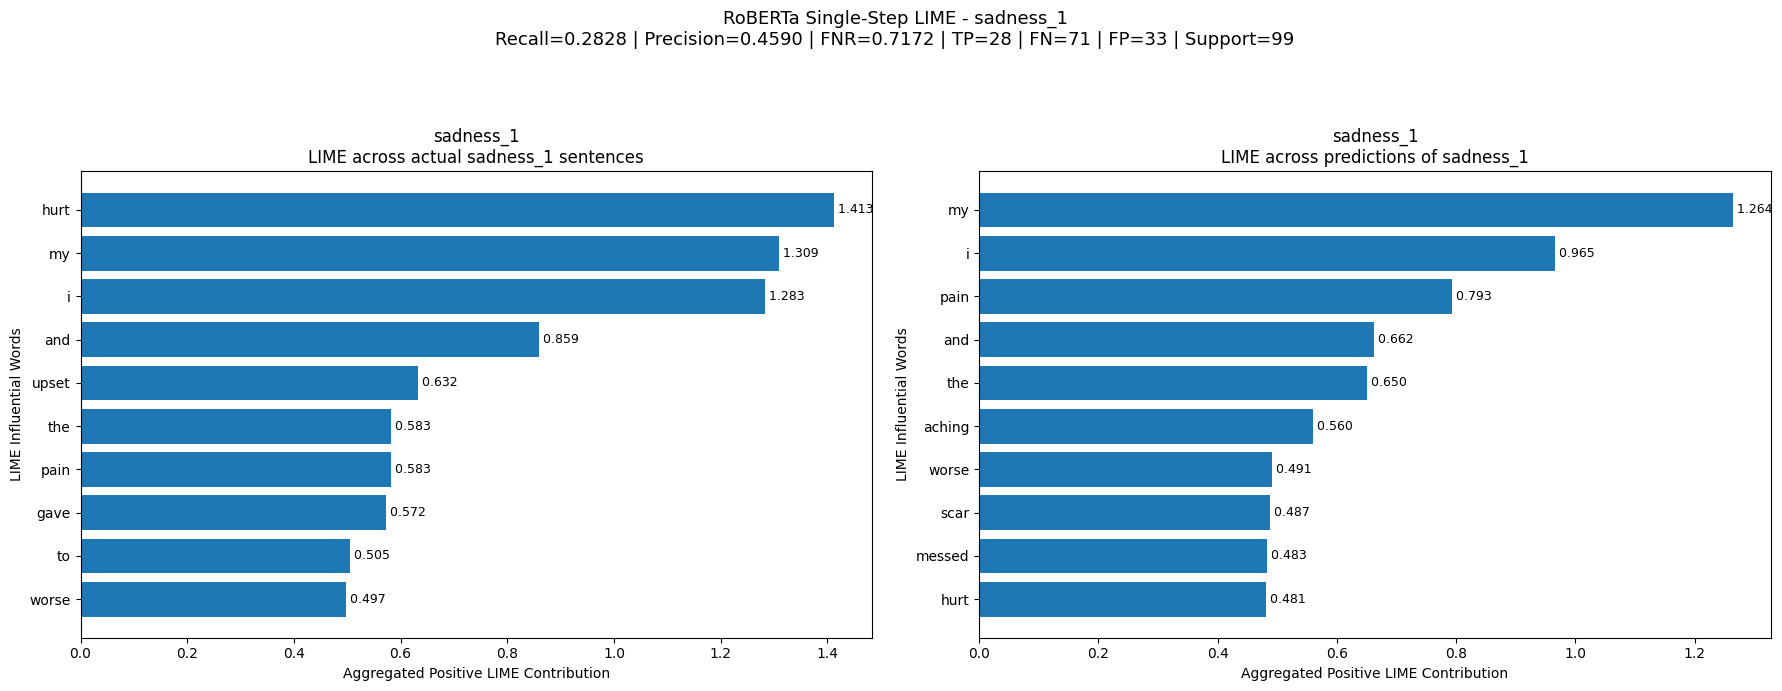

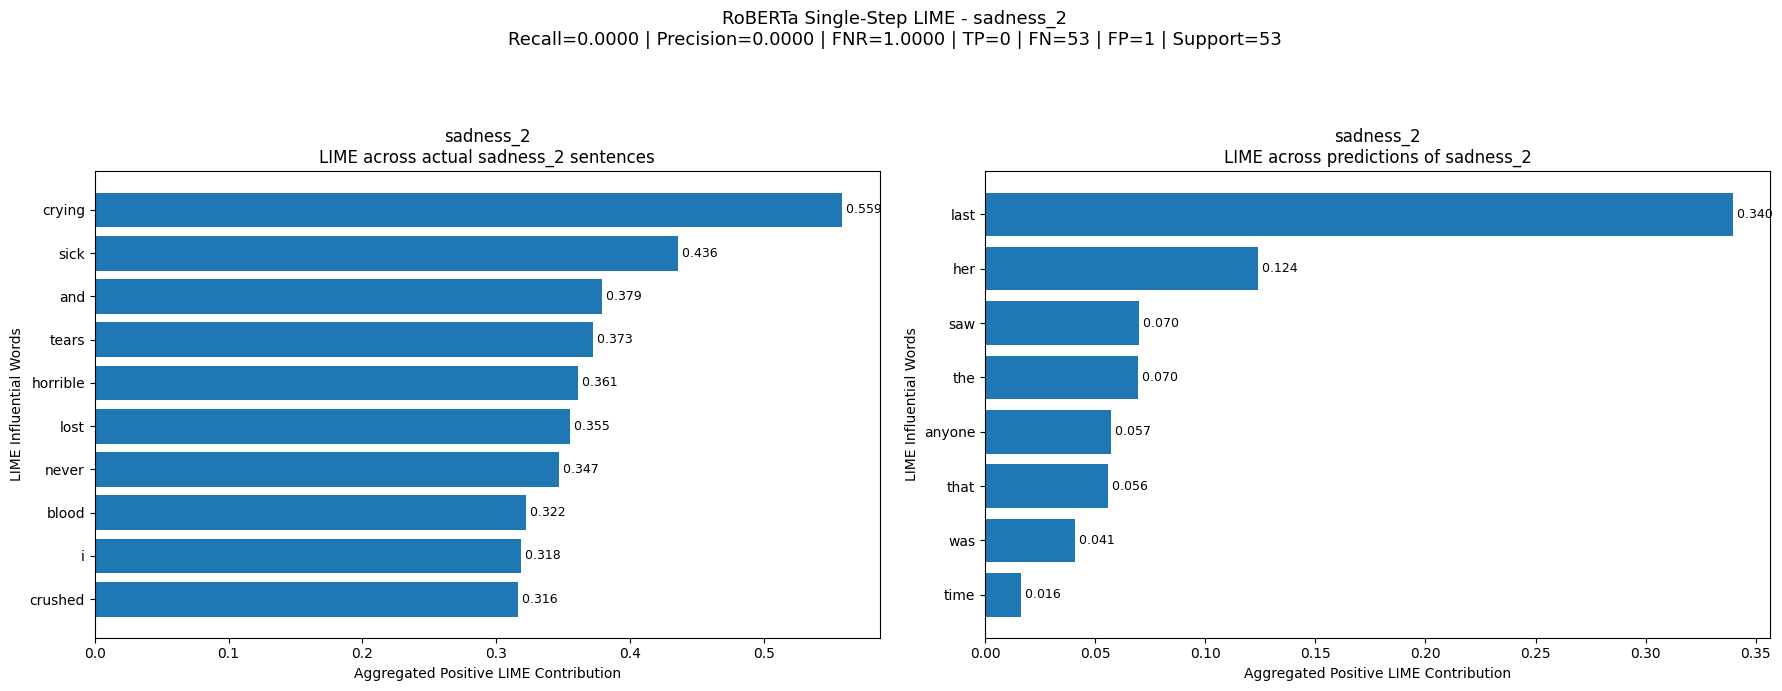

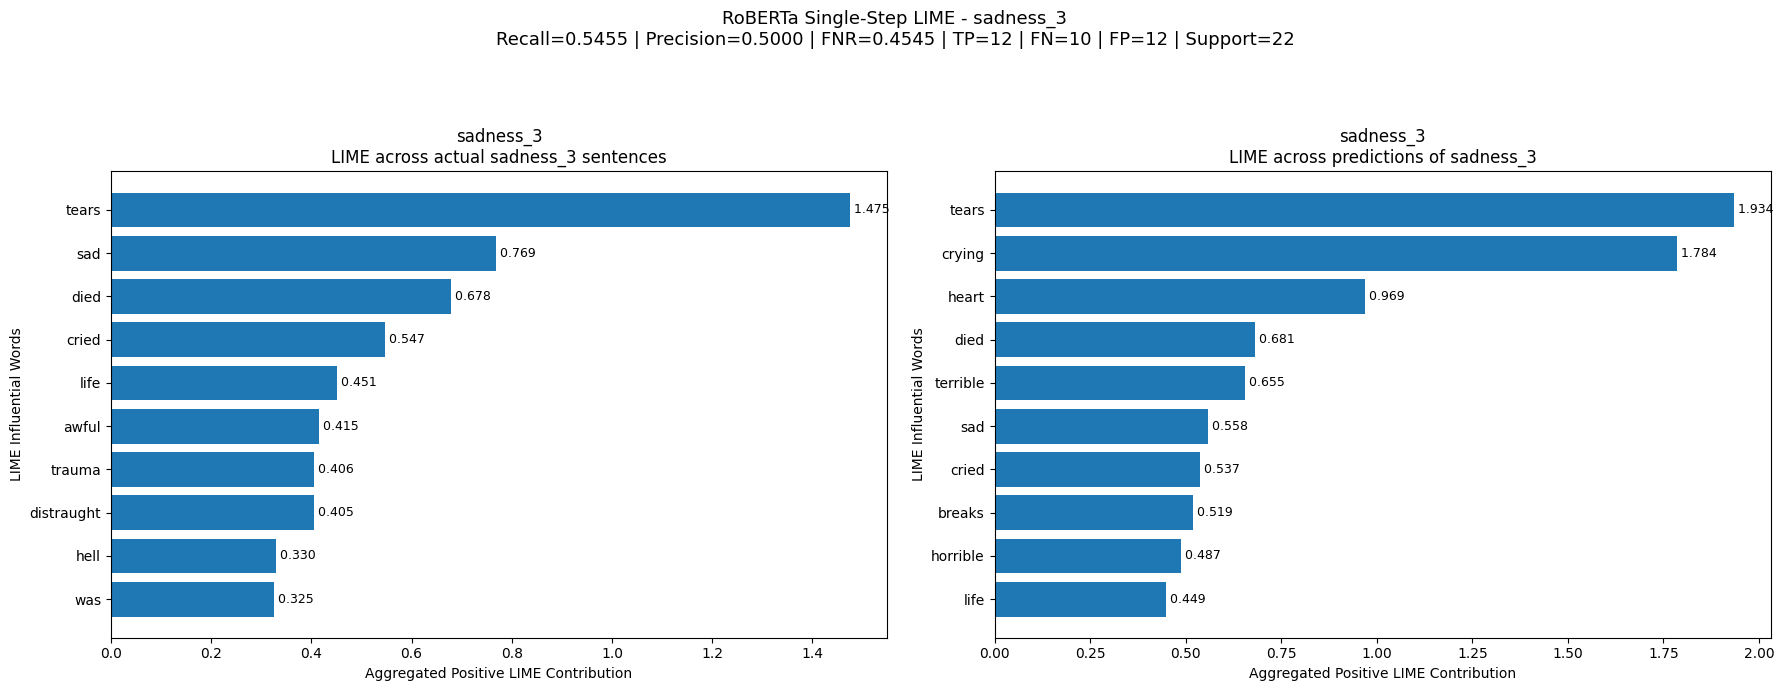

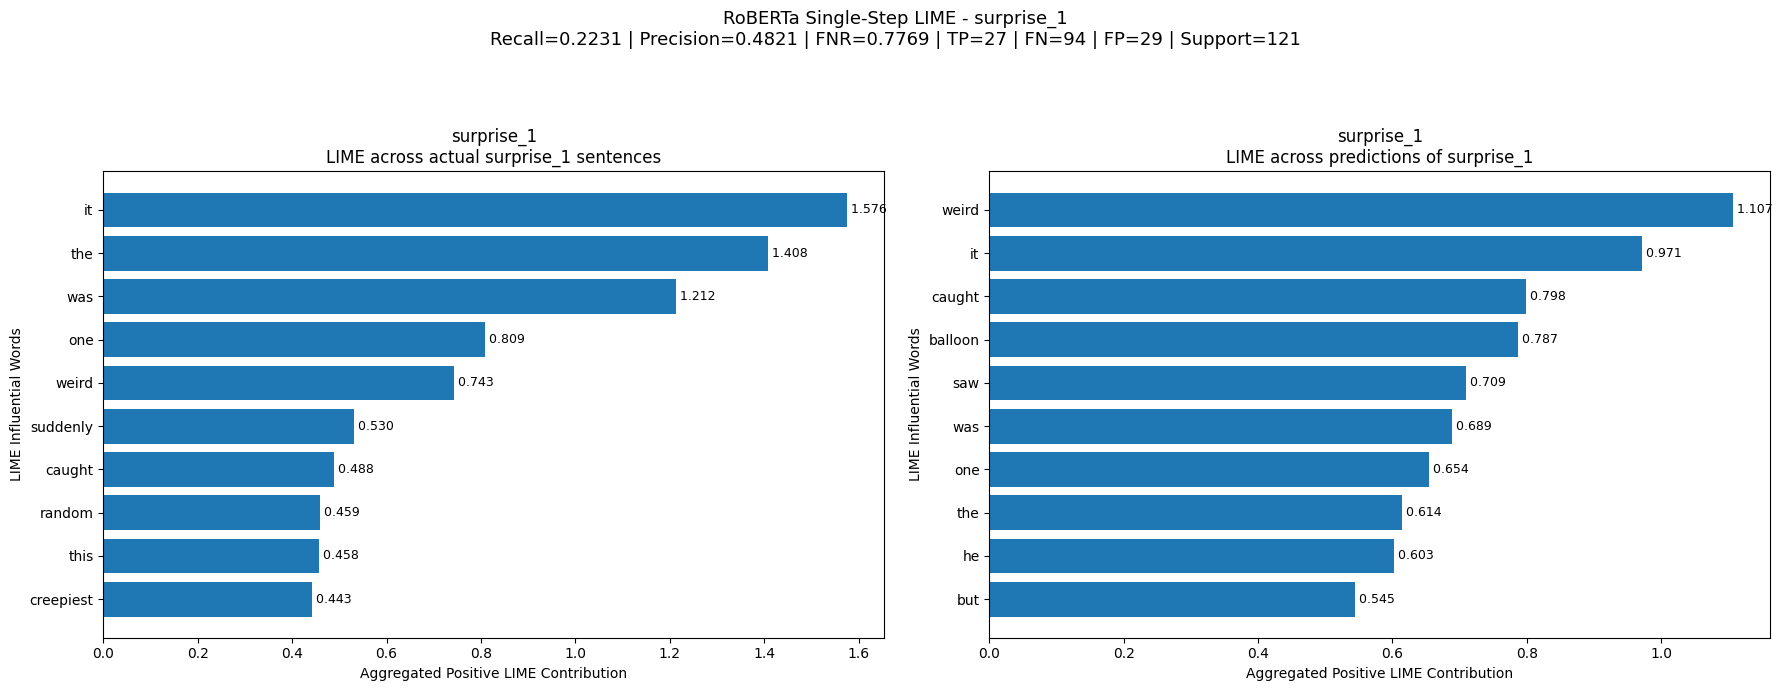

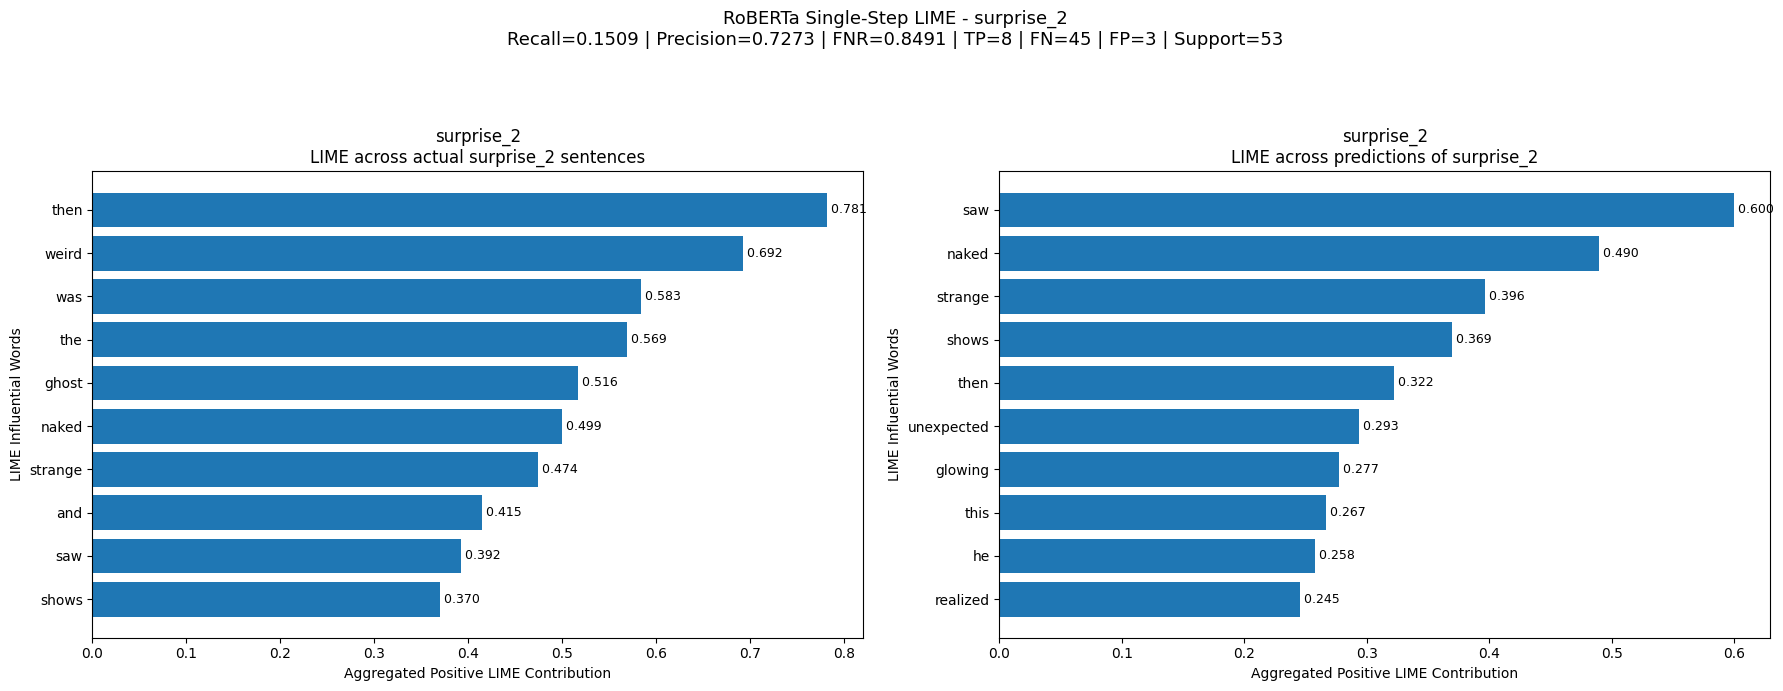

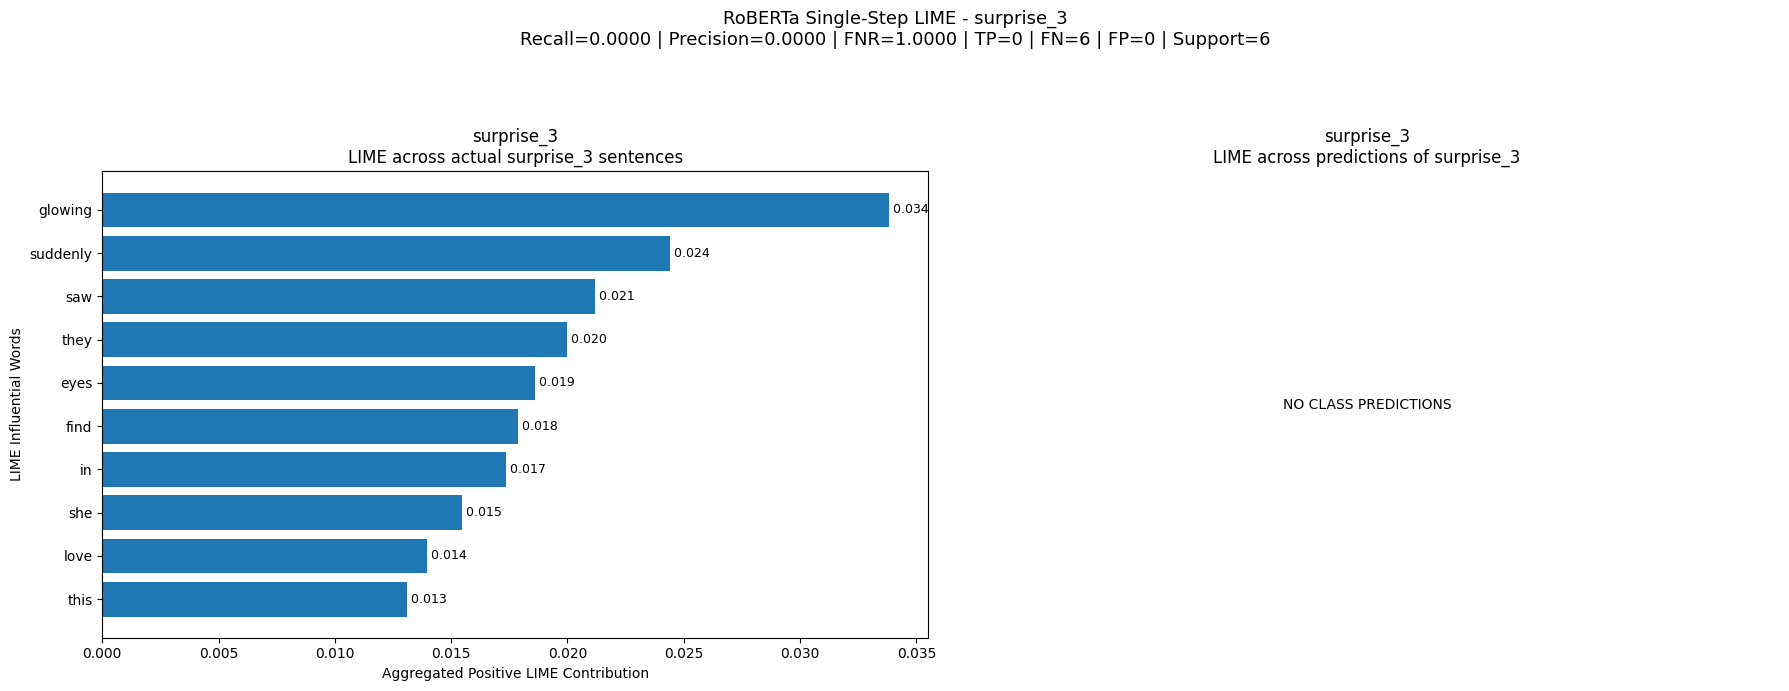


ROBERTA ANALYSIS COMPLETED

Training log:
/content/drive/MyDrive/RoBERTa_SingleStep_log.csv

Training log columns:
class | precision | recall | f1_score | TP | TN | FN | FP | support

LIME CSV:
/content/drive/MyDrive/RoBERTa_SingleStep_LIME_Results.csv

LIME CSV columns:
class | recall | precision | fnr | TP | TN | FN | FP | support | true_class_lime_words | predicted_class_lime_words

All influential words in both columns come only from LIME.
No topic classifier, keyword extractor, sentiment dictionary or POS tagger is used.
The 15 LIME comparison visualizations are displayed only and are not saved.


In [4]:
# =========================================================
# 18. INSTALL LIME
# =========================================================
if importlib.util.find_spec("lime") is None:
    subprocess.check_call([sys.executable,"-m","pip","install","lime","-q"])
from lime.lime_text import LimeTextExplainer

# =========================================================
# 19. LIME SETTINGS
# =========================================================
LIME_MAX_LENGTH=128
LIME_NUM_SAMPLES=1000
LIME_BATCH_SIZE=64
TOP_WORDS_VISUAL=10

lime_model=trainer.model.to(device)
lime_model.eval()

# =========================================================
# 20. MODEL PREDICTION FUNCTION FOR LIME
# =========================================================
def lime_predict_probabilities(texts):
    if isinstance(texts,str):
        texts=[texts]

    all_probs=[]

    for start in range(0,len(texts),LIME_BATCH_SIZE):
        batch=texts[start:start+LIME_BATCH_SIZE]

        inputs=tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=LIME_MAX_LENGTH,
            return_tensors="pt"
        )

        inputs={k:v.to(device) for k,v in inputs.items()}

        with torch.no_grad():
            outputs=lime_model(**inputs)
            probs=torch.sigmoid(outputs.logits)

        all_probs.append(probs.cpu().numpy())

    return np.vstack(all_probs)

# =========================================================
# 21. CLASS-SPECIFIC LIME PREDICTOR
# =========================================================
def create_lime_predictor(target_label):
    class_index=label2id[target_label]

    def predictor(texts):
        probs=lime_predict_probabilities(texts)
        positive=probs[:,class_index]
        negative=1-positive
        return np.column_stack([negative,positive])

    return predictor

# =========================================================
# 22. NORMALIZE LIME WORD
# =========================================================
def normalize_word(word):
    word=str(word).lower().strip()
    word=re.sub(r"[^a-z0-9'_]+","",word)
    return word if word else None

# =========================================================
# 23. AGGREGATE LIME WORDS
# =========================================================
# Important:
# Every word stored here comes directly from LIME.
# No topic classifier, lexicon or keyword extractor is used.
# =========================================================
def aggregate_lime_words(indices,target_label,label_name):
    if len(indices)==0:
        return [],f"NO {label_name.upper()}"

    explainer=LimeTextExplainer(
        class_names=[f"NOT_{target_label}",target_label],
        split_expression=r"\W+",
        bow=True,
        random_state=SEED
    )

    predictor=create_lime_predictor(target_label)
    word_weights={}

    for count,test_index in enumerate(indices,start=1):
        sentence=str(test_texts[test_index])

        sentence_tokens=re.findall(r"\b[\w']+\b",sentence.lower())
        unique_tokens=list(dict.fromkeys(sentence_tokens))
        num_features=max(1,len(unique_tokens))

        try:
            explanation=explainer.explain_instance(
                text_instance=sentence,
                classifier_fn=predictor,
                labels=[1],
                num_features=num_features,
                num_samples=LIME_NUM_SAMPLES
            )

            lime_values=explanation.as_list(label=1)

            for word,weight in lime_values:
                if weight<=0:
                    continue

                word=normalize_word(word)

                if word is None:
                    continue

                if word not in word_weights:
                    word_weights[word]=0.0

                word_weights[word]+=float(weight)

        except Exception as e:
            print(f"LIME error | {target_label} | index {test_index} | {e}")

        if count%20==0 or count==len(indices):
            print(f"{target_label} {label_name}: {count}/{len(indices)}")

    sorted_words=sorted(
        word_weights.items(),
        key=lambda x:x[1],
        reverse=True
    )

    word_string="; ".join(
        f"{word} ({weight:.4f})"
        for word,weight in sorted_words
    )

    return sorted_words,word_string

# =========================================================
# 24. TRUE-CLASS + PREDICTED-CLASS LIME AGGREGATION
# =========================================================
lime_rows=[]
true_visualization_data={}
predicted_visualization_data={}

print("\n"+"="*90)
print("AGGREGATED LIME ANALYSIS")
print("="*90)

for class_number,target_label in enumerate(LABELS,start=1):
    class_index=label2id[target_label]

    true_class=final_true_labels[:,class_index]
    predicted_class=final_predictions[:,class_index]

    tp=int(np.sum((true_class==1)&(predicted_class==1)))
    tn=int(np.sum((true_class==0)&(predicted_class==0)))
    fn=int(np.sum((true_class==1)&(predicted_class==0)))
    fp=int(np.sum((true_class==0)&(predicted_class==1)))

    support=int(np.sum(true_class==1))

    row=final_report.get(target_label,{})
    recall=float(row.get("recall",0.0))
    precision=float(row.get("precision",0.0))
    fnr=fn/(tp+fn) if (tp+fn)>0 else 0.0

    true_indices=np.where(true_class==1)[0]
    predicted_indices=np.where(predicted_class==1)[0]

    print("\n"+"-"*70)
    print(f"[{class_number}/{len(LABELS)}] {target_label}")
    print(f"True class sentences: {len(true_indices)}")
    print(f"Predicted class sentences: {len(predicted_indices)}")

    true_words,true_word_string=aggregate_lime_words(
        true_indices,
        target_label,
        "true class sentences"
    )

    predicted_words,predicted_word_string=aggregate_lime_words(
        predicted_indices,
        target_label,
        "class predictions"
    )

    true_visualization_data[target_label]=true_words
    predicted_visualization_data[target_label]=predicted_words

    lime_rows.append({
        "class":target_label,
        "recall":round(recall,4),
        "precision":round(precision,4),
        "fnr":round(fnr,4),
        "TP":tp,
        "TN":tn,
        "FN":fn,
        "FP":fp,
        "support":support,
        "true_class_lime_words":true_word_string,
        "predicted_class_lime_words":predicted_word_string
    })

# =========================================================
# 25. SAVE ONE LIME CSV
# =========================================================
lime_results_df=pd.DataFrame(lime_rows)

lime_results_df=lime_results_df[
    [
        "class",
        "recall",
        "precision",
        "fnr",
        "TP",
        "TN",
        "FN",
        "FP",
        "support",
        "true_class_lime_words",
        "predicted_class_lime_words"
    ]
]

lime_results_df.to_csv(
    LIME_RESULT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("\n"+"="*100)
print("FINAL LIME RESULTS")
print("="*100)
display(lime_results_df)
print("\nSaved:",LIME_RESULT_FILE)

# =========================================================
# 26. VISUALIZATIONS FOR ALL 15 CLASSES
# =========================================================
# Left  = LIME words from all true-class sentences
# Right = LIME words from sentences actually predicted
#         as the class
#
# Displayed only. Nothing is saved.
# =========================================================
for target_label in LABELS:
    true_words=true_visualization_data.get(target_label,[])[:TOP_WORDS_VISUAL]
    predicted_words=predicted_visualization_data.get(target_label,[])[:TOP_WORDS_VISUAL]

    fig,axes=plt.subplots(1,2,figsize=(18,7))

    if len(true_words)>0:
        names=[x[0] for x in true_words][::-1]
        values=[x[1] for x in true_words][::-1]
        bars=axes[0].barh(names,values)

        for bar,value in zip(bars,values):
            axes[0].text(
                bar.get_width(),
                bar.get_y()+bar.get_height()/2,
                f" {value:.3f}",
                va="center",
                fontsize=9
            )

        axes[0].set_xlabel("Aggregated Positive LIME Contribution")
        axes[0].set_ylabel("LIME Influential Words")
    else:
        axes[0].text(0.5,0.5,"No true-class LIME words",ha="center",va="center")
        axes[0].axis("off")

    axes[0].set_title(
        f"{target_label}\nLIME across actual {target_label} sentences"
    )

    if len(predicted_words)>0:
        names=[x[0] for x in predicted_words][::-1]
        values=[x[1] for x in predicted_words][::-1]
        bars=axes[1].barh(names,values)

        for bar,value in zip(bars,values):
            axes[1].text(
                bar.get_width(),
                bar.get_y()+bar.get_height()/2,
                f" {value:.3f}",
                va="center",
                fontsize=9
            )

        axes[1].set_xlabel("Aggregated Positive LIME Contribution")
        axes[1].set_ylabel("LIME Influential Words")
    else:
        axes[1].text(0.5,0.5,"NO CLASS PREDICTIONS",ha="center",va="center")
        axes[1].axis("off")

    axes[1].set_title(
        f"{target_label}\nLIME across predictions of {target_label}"
    )

    metrics=lime_results_df[
        lime_results_df["class"]==target_label
    ].iloc[0]

    fig.suptitle(
        f"RoBERTa Single-Step LIME - {target_label}\n"
        f"Recall={metrics['recall']:.4f} | "
        f"Precision={metrics['precision']:.4f} | "
        f"FNR={metrics['fnr']:.4f} | "
        f"TP={metrics['TP']} | FN={metrics['FN']} | FP={metrics['FP']} | "
        f"Support={metrics['support']}",
        fontsize=13
    )

    plt.tight_layout(rect=[0,0,1,0.91])
    plt.show()
    plt.close(fig)

# =========================================================
# 27. FINISHED
# =========================================================
print("\n"+"="*100)
print("ROBERTA ANALYSIS COMPLETED")
print("="*100)

print("\nTraining log:")
print(LOG_FILE)

print("\nTraining log columns:")
print("class | precision | recall | f1_score | TP | TN | FN | FP | support")

print("\nLIME CSV:")
print(LIME_RESULT_FILE)

print("\nLIME CSV columns:")
print(
    "class | recall | precision | fnr | TP | TN | FN | FP | support | "
    "true_class_lime_words | predicted_class_lime_words"
)

print("\nAll influential words in both columns come only from LIME.")
print("No topic classifier, keyword extractor, sentiment dictionary or POS tagger is used.")
print("The 15 LIME comparison visualizations are displayed only and are not saved.")